# OG

In [1]:
import sys
import json
import numpy as np
import cv2
import pyk4a
from pyk4a import PyK4A, Config
from rtmlib import BodyWithFeet
from halpe26 import halpe26
from utils import create_filters, get_pose, BoneConsistencyFilter, PullTestMonitor, RealTimeViewer
import time
from PyQt5.QtWidgets import QApplication
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

from OneEuroFilter import OneEuroFilter

In [ ]:
# pose estimation model setup
body_with_feet = BodyWithFeet(
    to_openpose=False, mode="performance", backend="onnxruntime", device="cuda"
)
with open("properties.json", "r") as f:
    properties = json.load(f)

# valid depth interval
clip_depth = [500.0, 5000.0]
confidence_thr = 0.5
radius = 2

# kinect configuration
config = Config(
    color_format=pyk4a.ImageFormat.COLOR_BGRA32,
    color_resolution=pyk4a.ColorResolution.RES_720P,
    depth_mode=pyk4a.DepthMode.NFOV_2X2BINNED,
    synchronized_images_only=True,
    camera_fps=pyk4a.FPS.FPS_30,
    depth_delay_off_color_usec=0,
    wired_sync_mode=pyk4a.WiredSyncMode.STANDALONE,
    subordinate_delay_off_master_usec=0,
    disable_streaming_indicator=True,
)

# Initialize pose container and filters
keypoints_3d = np.full((properties["pose"]["keypoints_count"], 5), np.nan)
pose_sequence = np.copy(keypoints_3d)

# TODO: is this necessary?
pose_filters = create_filters(
    num_keypoints=properties["pose"]["keypoints_count"],
    freq=pyk4a.FPS.FPS_30,
    min_cutoff=1.0,
    beta=0.3,
)
single_filter = OneEuroFilter(freq=pyk4a.FPS.FPS_30, mincutoff=1.0, beta=0.3)
bone_filter = BoneConsistencyFilter(halpe26, fps=30)


# initialize & start kinect
k4a = PyK4A(config=config)
k4a.start()

frame_times = []  # List to store timestamps of the last frames


# Initialize QApplication (needed for RealTiemViewer)
app = QApplication(sys.argv)
# Initialize RealTimeViewer and PullTestMonitor
viewer = RealTimeViewer(halpe26)
pull_test_monitor = PullTestMonitor(properties, halpe26)

while viewer.isopen:
    capture = k4a.get_capture()
    current_time = time.time()
    frame_times.append(current_time)
    # Calculate the averaged FPS
    FPS = len(frame_times)
    # Remove frames older than 1 second
    frame_times = [t for t in frame_times if current_time - t <= 1.0]

    if np.any(capture.color):
        color = capture.color[:, :, :3]
        # TODO: check if this is correct size
        color = cv2.resize(color, (color.shape[1] // 4, color.shape[0] // 4))

        # get pointcloud (x,y,depth)
        pointcloud = capture.transformed_depth_point_cloud
        pointcloud = cv2.resize(pointcloud, (pointcloud.shape[1] // 4, pointcloud.shape[0] // 4))
        pointcloud = pointcloud.astype(float)

        # clip pointcloud to custom depth range
        mask = (pointcloud[:, :, 2] >= clip_depth[0]) & (pointcloud[:, :, 2] <= clip_depth[1])
        pointcloud[~mask] = np.nan

        # 2D inference, picking person with the highest overall confidence score
        keypoints_2d, scores = body_with_feet(color)
        best_idx = np.nanargmax(np.nansum(scores, axis=1))
        keypoints_2d, scores = keypoints_2d[best_idx], scores[best_idx]

        # 3D keypoints from Kinect (num_kpts × 5(timestamp,x,depth,y,scores))
        keypoints_3d = get_pose(
            keypoints_2d, scores, pointcloud, confidence_thr, radius, keypoints_3d, current_time
        )
        if keypoints_3d is not None:
            # Apply filtering
            timestamp = time.time()
            keypoints_3d_euro_filtered = keypoints_3d
            # filtered_pose_2 = keypoints_3d

            # Check all dimensions at once for nans
            valid_keypoints = ~np.isnan(keypoints_3d).any(axis=1)  
            # filter valid 3D keypoints
            for kpt_idx in np.where(valid_keypoints)[0]:
                keypoints_3d_euro_filtered[kpt_idx][1] = pose_filters[kpt_idx]["x"](keypoints_3d[kpt_idx][1], timestamp)
                keypoints_3d_euro_filtered[kpt_idx][2] = pose_filters[kpt_idx]["y"](keypoints_3d[kpt_idx][2], timestamp)
                keypoints_3d_euro_filtered[kpt_idx][3] = pose_filters[kpt_idx]["z"](keypoints_3d[kpt_idx][3], timestamp)

                # filtered_pose_2[kpt_idx][1] = single_filter(keypoints_3d[kpt_idx][1], timestamp)
                # filtered_pose_2[kpt_idx][2] = single_filter(keypoints_3d[kpt_idx][2], timestamp)
                # filtered_pose_2[kpt_idx][3] = single_filter(keypoints_3d[kpt_idx][3], timestamp)
                

            keypoints_3d_no_filter = bone_filter(keypoints_3d)

            # apply bone lenght consistency filter
            keypoints_3d_bone_filtered = bone_filter(keypoints_3d_euro_filtered)

            # store the valid keypoint data for all frames (num_keypoints(26) × dims(5) × frames)
            pose_sequence = np.dstack((pose_sequence, keypoints_3d_bone_filtered))

            (
                BOS,
                xCOM,
                stability,
                baseline_met,
                step_time,
                nsteps,
                step_events,
                pull_time,
                pull_magn,
            ) = pull_test_monitor.update(pose_sequence, FPS)

            # Update the viewer
            viewer.update(
                pose_sequence[:, :, -1],
                FPS,
                bos=BOS,
                xcom=xCOM,
                stability=stability,
                baseline_met=baseline_met,
            )

k4a.stop()

# TODO: figure out how to close this shit properly
# Exit the QApplication
# QApplication.exit()
# sys.exit(app.exec_())
# app.exit()
# sys.exit(0)
app.quit()

d:\munger\PullTest\pull_test_evn\Lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


load C:\Users\munger\.cache\rtmlib\hub\checkpoints\yolox_x_8xb8-300e_humanart-a39d44ed.onnx with onnxruntime backend
load C:\Users\munger\.cache\rtmlib\hub\checkpoints\rtmpose-x_simcc-body7_pt-body7-halpe26_700e-384x288-7fb6e239_20230606.onnx with onnxruntime backend


In [ ]:
color.shape, body_with_feet.det_model.model_input_size, body_with_feet.pose_model.model_input_size

In [3]:
print(pose_sequence.shape)

(26, 5, 115)


In [8]:
5%2

1

In [ ]:
a = np.array(['timestamp','x','y','depth','score'])
print(a)
print(a[3])

## smooting (savgol filter)

In [4]:
from scipy.signal import savgol_filter, find_peaks
import matplotlib.pyplot as plt

smoothed_sequence = np.copy(pose_sequence)
window_length = 5
polyorder = 2

for kpt_idx in range(pose_sequence.shape[0]):
    for dim in range(1, 4):  # Smooth x, y, z dimensions (skip timestamp)
        if not np.isnan(pose_sequence[kpt_idx, dim, :]).all():
            smoothed_sequence[kpt_idx, dim, :] = savgol_filter(
                pose_sequence[kpt_idx, dim, :],
                window_length=window_length,
                polyorder=polyorder,
                mode="nearest",
            )

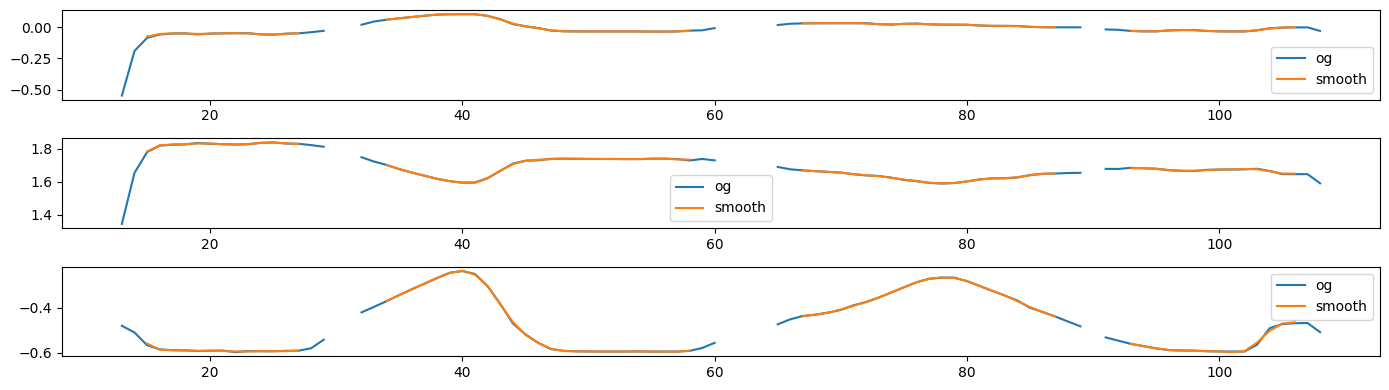

In [6]:
kpt_idx_vis = 15

fig, axs = plt.subplots(3,1,figsize=(14,4))
axs[0].plot(pose_sequence[kpt_idx_vis,1,:], label='og')
axs[1].plot(pose_sequence[kpt_idx_vis,2,:], label='og')
axs[2].plot(pose_sequence[kpt_idx_vis,3,:], label='og')

axs[0].plot(smoothed_sequence[kpt_idx_vis,1,:],label='smooth')
axs[1].plot(smoothed_sequence[kpt_idx_vis,2,:],label='smooth')
axs[2].plot(smoothed_sequence[kpt_idx_vis,3,:],label='smooth')

for ax in axs:
    ax.legend()
plt.tight_layout()

In [ ]:
if pose_sequence[:,:-2,:].shape[1] < 4:
    padding = np.full(
        (pose_sequence.shape[0], 4 - pose_sequence.shape[1], pose_sequence.shape[2]), np.nan
    )
    pose_sequence_padded = np.concatenate((pose_sequence, padding), axis=1)

pose_sequence_padded.shape

# Test

In [ ]:
import cv2
import numpy as np

import pyk4a
from pyk4a import Config, PyK4A
from rtmlib import BodyWithFeet
from utils import Custom
import json

with open("./models.json",'r') as f:
    models = json.load(f)

device = "cuda"  # cpu, cuda, mps
backend = "onnxruntime"  # opencv, onnxruntime, openvino
detector_name = 'YOLOX_nano' # 'YOLOX_l_COCO','YOLOX_nano','YOLOX_tiny','YOLOX_s','YOLOX_m','YOLOX_l','YOLOX_x'
pose_name = 'RTMPose_x' # (26) 'RTMPose_t', 'RTMPose_s', 'RTMPose_m', 'RTMPose_l', 'RTMPose_m2', 'RTMPose_l2', 'RTMPose_x', (133) 'RTMW_l', 'RTMW_x'
kpt_labels = models['pose_models']["26"]["kpt_labels"]

custom = Custom(det_class='YOLOX', #'RTMDet',
                det=models['detectors'][detector_name]['path'],
                det_input_size=models['detectors'][detector_name]['input_size'],
                pose_class='RTMPose',
                pose=models['pose_models']["26"]["models"][pose_name]['path'],
                pose_input_size=models['pose_models']["26"]["models"][pose_name]['input_size'],
                backend=backend,
                device=device)

In [ ]:



# body_with_feet = BodyWithFeet(
#     to_openpose=False, mode="performance", backend="onnxruntime", device="cuda"
# )


# kinect configuration
config = Config(
    color_format=pyk4a.ImageFormat.COLOR_BGRA32,
    color_resolution=pyk4a.ColorResolution.RES_720P,
    depth_mode=pyk4a.DepthMode.NFOV_2X2BINNED,
    synchronized_images_only=True,
    camera_fps=pyk4a.FPS.FPS_30,
    depth_delay_off_color_usec=0,
    wired_sync_mode=pyk4a.WiredSyncMode.STANDALONE,
    subordinate_delay_off_master_usec=0,
    disable_streaming_indicator=True,
)




k4a = PyK4A(config=config)
k4a.start()

# getters and setters directly get and set on device
k4a.whitebalance = 4500
assert k4a.whitebalance == 4500
k4a.whitebalance = 4510
assert k4a.whitebalance == 4510

while 1:
    capture = k4a.get_capture()
    color = capture.color

    if np.any(color):
        # resized_color = cv2.resize(color[:, :, :3], (color.shape[1] // 4, color.shape[0] // 4))
        color_rgb = color[:,:,:3]
        # keypoints, scores = body_with_feet(resized_color)
        keypoints_2d, scores = custom(color_rgb)

        cv2.imshow("k4a", capture.color[:, :, :3])
        key = cv2.waitKey(10)
        if key != -1:
            cv2.destroyAllWindows()
            break
k4a.stop()





In [ ]:
keypoints_2d.shape

In [ ]:
body_with_feet.det_model.model_input_size, body_with_feet.pose_model.model_input_size